# IN6227-Assignment-1 | Variant-1

HU YAOYAO

Repository: https://github.com/huyaoyao926/Data_Mining_Assignment-1

This notebook compares Logistic Regression and Random Forest for the supplied
yes/no classification task. It follows the same analysis reported in the
two-page submission. Place train.csv and test.csv in a dataset/ folder
beside this notebook, then run the cells in order.

## 1. Load the data

The expected layout is this notebook beside dataset/train.csv and
dataset/test.csv. Run Jupyter from that parent folder. If the CSV files
are elsewhere, set IN6227_DATA_DIR to the folder containing both files.

In [3]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, make_scorer, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

try:
    from IPython.display import display as show
except ImportError:
    def show(value):
        if isinstance(value, pd.DataFrame):
            print(value.to_string(index=False))
        elif isinstance(value, Image.Image):
            print("Figure created.")
        else:
            print(value)

RANDOM_STATE = 42
TARGET = "label"
NEGATIVE = "no"
POSITIVE = "yes"
DATA_DIR = Path(os.environ.get("IN6227_DATA_DIR", "dataset"))
if not (DATA_DIR / "train.csv").is_file() or not (DATA_DIR / "test.csv").is_file():
    raise FileNotFoundError(
        f"Expected train.csv and test.csv in {DATA_DIR.resolve()}. "
        "Run Jupyter from the notebook folder or set IN6227_DATA_DIR."
    )
data_dir = DATA_DIR
train_raw = pd.read_csv(data_dir / "train.csv")
test_raw = pd.read_csv(data_dir / "test.csv")
if list(train_raw.columns) != list(test_raw.columns):
    raise ValueError("The train and test columns differ.")
if TARGET not in train_raw.columns:
    raise ValueError("The target column is missing.")
labels = set(pd.concat([train_raw[TARGET], test_raw[TARGET]]).dropna())
if labels != {NEGATIVE, POSITIVE}:
    raise ValueError(f"Expected no/yes labels, found {sorted(labels)}.")

print(f"Training rows: {len(train_raw):,}; test rows: {len(test_raw):,}")
print(f"Columns: {len(train_raw.columns)} including the target")

Training rows: 31,112; test rows: 13,334
Columns: 16 including the target


## 2. Check the training data

The training set has more no cases than yes cases, so accuracy alone would
give an incomplete picture. Missing labels cannot be used for supervised
training or evaluation. Missing predictors stay in the data and are
imputed within the cross-validation pipeline. The IQR counts below are
descriptive checks, not a rule for deleting observations.

In [5]:
predictors = [column for column in train_raw.columns if column != TARGET]
numeric_columns = train_raw[predictors].select_dtypes(include=np.number).columns.tolist()
categorical_columns = [c for c in predictors if c not in numeric_columns]

checks = pd.DataFrame([
    ["Rows", len(train_raw), len(test_raw)],
    ["Missing target labels", train_raw[TARGET].isna().sum(), test_raw[TARGET].isna().sum()],
    ["Missing predictor cells", train_raw[predictors].isna().sum().sum(),
     test_raw[predictors].isna().sum().sum()],
    ["Duplicate rows", train_raw.duplicated().sum(), test_raw.duplicated().sum()],
], columns=["Check", "Train", "Test"])
show(checks)

class_counts = train_raw[TARGET].value_counts(dropna=True).reindex([NEGATIVE, POSITIVE])
class_table = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.to_numpy(),
    "Share": (class_counts / class_counts.sum()).to_numpy(),
})
show(class_table)
print(f"Numeric predictors: {len(numeric_columns)}; categorical predictors: {len(categorical_columns)}")

iqr_counts = {}
for column in numeric_columns:
    q1, q3 = train_raw[column].quantile([0.25, 0.75])
    lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    iqr_counts[column] = int(((train_raw[column] < lower) |
                              (train_raw[column] > upper)).sum())
show(pd.DataFrame({"Numeric predictor": iqr_counts.keys(),
                   "Outside 1.5 IQR": iqr_counts.values()}))

,Check,Train,Test
0,Rows,31112,13334
1,Missing target labels,3,1
2,Missing predictor cells,47,20
3,Duplicate rows,0,0


,Class,Count,Share
0,no,23645,0.760069
1,yes,7464,0.239931


Numeric predictors: 7; categorical predictors: 8


,Numeric predictor,Outside 1.5 IQR
0,aptitude_score,617
1,performance_score,154
2,stability_index,1128
3,load_ratio,2527
4,index_weight,1017
5,activity_duration,5350
6,composite_rank,115


## 3. Prepare predictors

Three training rows and one test row lack a class label, so they are
excluded. All 15 predictors are retained. Numeric gaps receive the
training-fold median; categorical gaps receive the training-fold mode.
Categories are one-hot encoded, and unseen categories are ignored. Robust
scaling is used only for Logistic Regression because several numeric
variables have long tails. Keeping these operations in each pipeline
prevents validation folds from influencing their own preprocessing.

In [7]:
train = train_raw.dropna(subset=[TARGET]).copy()
test = test_raw.dropna(subset=[TARGET]).copy()
X_train, y_train = train.drop(columns=TARGET), train[TARGET]
X_test, y_test = test.drop(columns=TARGET), test[TARGET]

def make_preprocessor(robust_scale):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if robust_scale:
        numeric_steps.append(("scale", RobustScaler()))
    categorical_steps = [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_columns),
        ("categorical", Pipeline(categorical_steps), categorical_columns),
    ])

print(f"Labeled training rows: {len(train):,}; labeled test rows: {len(test):,}")

Labeled training rows: 31,109; labeled test rows: 13,333


## 4. Tune two classifiers on the training set

Logistic Regression is a linear benchmark. Random Forest can learn
nonlinear relationships and interactions. Both models compensate for the
class imbalance with class weights. A stratified five-fold search chooses
hyperparameters by mean ROC-AUC. The search is limited to the supplied
training data. The test set is held back until the next section.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": make_scorer(f1_score, pos_label=POSITIVE, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": make_scorer(
        average_precision_score,
        response_method="predict_proba",
        pos_label=POSITIVE,
    ),
}

logistic = Pipeline([
    ("preprocess", make_preprocessor(robust_scale=True)),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=2500, random_state=RANDOM_STATE,
    )),
])
forest = Pipeline([
    ("preprocess", make_preprocessor(robust_scale=False)),
    ("model", RandomForestClassifier(
        class_weight="balanced_subsample", n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])
searches = {
    "Logistic Regression": GridSearchCV(
        logistic, {"model__C": [0.1, 1.0, 10.0]},
        scoring=scoring, refit="roc_auc", cv=cv, n_jobs=-1,
    ),
    "Random Forest": GridSearchCV(
        forest, {
            "model__n_estimators": [250],
            "model__max_depth": [None, 18],
            "model__min_samples_leaf": [1, 3],
            "model__max_features": ["sqrt"],
        }, scoring=scoring, refit="roc_auc", cv=cv, n_jobs=-1,
    ),
}

for name, search in searches.items():
    print(f"Fitting {name}...")
    search.fit(X_train, y_train)
    print(f"Selected settings: {search.best_params_}")

Fitting Logistic Regression...
Selected settings: {'model__C': 1.0}
Fitting Random Forest...
Selected settings: {'model__max_depth': 18, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 250}


In [10]:
cv_rows = []
for name, search in searches.items():
    index = search.best_index_
    cv_rows.append({
        "Model": name,
        "Accuracy": search.cv_results_["mean_test_accuracy"][index],
        "Balanced accuracy": search.cv_results_["mean_test_balanced_accuracy"][index],
        "F1 (yes)": search.cv_results_["mean_test_f1"][index],
        "ROC-AUC": search.cv_results_["mean_test_roc_auc"][index],
        "Average precision": search.cv_results_["mean_test_average_precision"][index],
        "ROC-AUC SD": search.cv_results_["std_test_roc_auc"][index],
    })
cv_table = pd.DataFrame(cv_rows)
show(cv_table.round(3))

,Model,Accuracy,Balanced accuracy,F1 (yes),ROC-AUC,Average precision,ROC-AUC SD
0,Logistic Regression,0.790,0.810,0.660,0.890,0.706,0.004
1,Random Forest,0.806,0.804,0.664,0.891,0.713,0.004


## 5. Evaluate on the held-out test set

Each tuned search refits its selected pipeline on all labeled training
rows. Predictions are then made once on the labeled test rows. The
threshold is the classifier's default decision rule. ROC-AUC and average
precision use predicted probabilities, while the other metrics use class
predictions. In each confusion matrix, rows are actual classes and
columns are predicted classes.

In [12]:
evaluations = {}
for name, search in searches.items():
    model = search.best_estimator_
    predictions = model.predict(X_test)
    yes_column = list(model.classes_).index(POSITIVE)
    probabilities = model.predict_proba(X_test)[:, yes_column]
    binary_target = (y_test == POSITIVE).astype(int)
    matrix = confusion_matrix(y_test, predictions, labels=[NEGATIVE, POSITIVE])
    tn, fp, fn, tp = matrix.ravel()
    fpr, tpr, _ = roc_curve(binary_target, probabilities)
    evaluations[name] = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced accuracy": balanced_accuracy_score(y_test, predictions),
        "Precision (yes)": precision_score(y_test, predictions,
                                             pos_label=POSITIVE, zero_division=0),
        "Recall (yes)": recall_score(y_test, predictions,
                                      pos_label=POSITIVE, zero_division=0),
        "F1 (yes)": f1_score(y_test, predictions,
                              pos_label=POSITIVE, zero_division=0),
        "Specificity (no)": tn / (tn + fp),
        "ROC-AUC": roc_auc_score(binary_target, probabilities),
        "Average precision": average_precision_score(binary_target, probabilities),
        "Confusion matrix": matrix,
        "ROC curve": (fpr, tpr),
    }

test_table = pd.DataFrame([
    {"Model": name, **{key: value for key, value in scores.items()
                        if key not in {"Confusion matrix", "ROC curve"}}}
    for name, scores in evaluations.items()
])
show(test_table.round(3))
for name, scores in evaluations.items():
    print(name)
    show(pd.DataFrame(scores["Confusion matrix"],
                      index=["Actual no", "Actual yes"],
                      columns=["Predicted no", "Predicted yes"]))

,Model,Accuracy,Balanced accuracy,Precision (yes),Recall (yes),F1 (yes),Specificity (no),ROC-AUC,Average precision
0,Logistic Regression,0.784,0.805,0.529,0.843,0.650,0.766,0.888,0.699
1,Random Forest,0.804,0.804,0.562,0.803,0.661,0.805,0.890,0.705


Logistic Regression


,Predicted no,Predicted yes
Actual no,7784,2381
Actual yes,496,2672


Random Forest


,Predicted no,Predicted yes
Actual no,8181,1984
Actual yes,623,2545


## 6. Inspect the comparison

On 13,333 labeled test rows, Random Forest reaches 0.804 accuracy and
0.661 F1 for yes, compared with 0.784 and 0.650 for Logistic Regression.
Their ROC-AUC values are close (0.890 and 0.888). Logistic Regression has
higher yes recall (0.843 versus 0.803): it finds 127 more yes cases but
makes 397 more false alarms. With no stated cost for either type of error,
Random Forest is the more balanced choice here. A different decision
threshold could be considered if missing a yes case is especially costly.

In [14]:
logistic_cm = evaluations["Logistic Regression"]["Confusion matrix"]
forest_cm = evaluations["Random Forest"]["Confusion matrix"]
print(f"Extra yes cases found by Logistic Regression: "
      f"{logistic_cm[1, 1] - forest_cm[1, 1]:,}")
print(f"Extra false alarms from Logistic Regression: "
      f"{logistic_cm[0, 1] - forest_cm[0, 1]:,}")

rf_pipeline = searches["Random Forest"].best_estimator_
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_
top_indices = np.argsort(importances)[::-1][:10]
top_features = pd.DataFrame({
    "Encoded feature": feature_names[top_indices],
    "Forest importance": importances[top_indices],
})
show(top_features.round(4))

Extra yes cases found by Logistic Regression: 127
Extra false alarms from Logistic Regression: 397


,Encoded feature,Forest importance
0,categorical__weather_pattern_Monsoon,0.1430
1,numeric__aptitude_score,0.1076
2,numeric__composite_rank,0.1008
3,categorical__instrument_Cello,0.0921
4,numeric__performance_score,0.0647
5,numeric__stability_index,0.0642
6,numeric__activity_duration,0.0586
7,categorical__weather_pattern_Heatwave,0.0498
8,numeric__load_ratio,0.0419
9,numeric__index_weight,0.0276


## 7. Save a compact figure and results

The figure shows the test ROC curves and confusion matrices. The CSV files
retain the full-precision comparison tables. Feature importance describes
how this fitted forest split the data; it does not establish a causal
relationship.

Saved tables and figure in notebook_results/


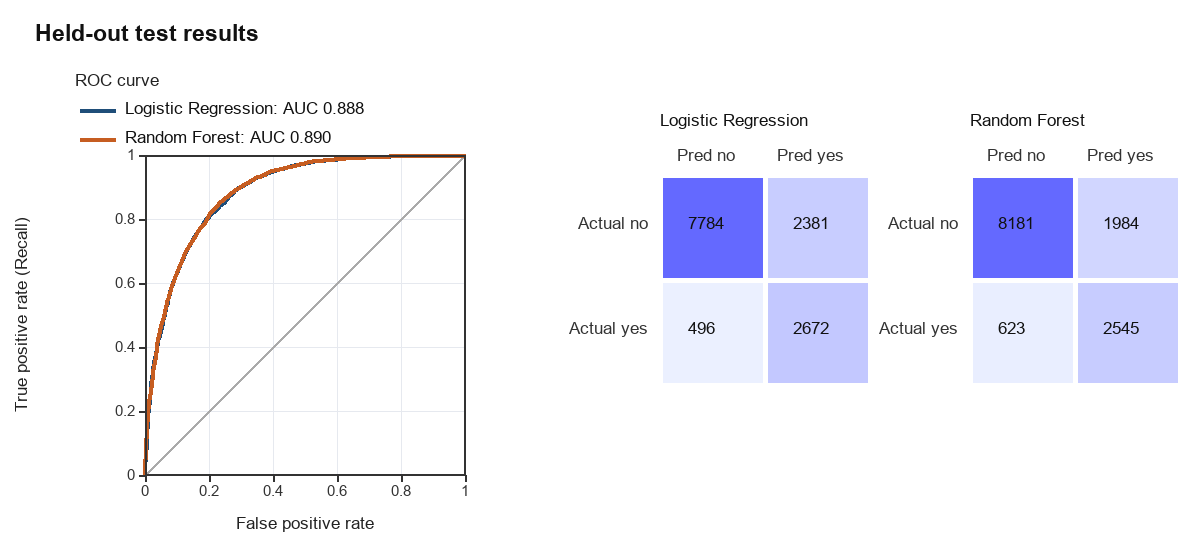

In [16]:
def get_font(size, bold=False):
    windows_font = Path("C:/Windows/Fonts/arialbd.ttf" if bold else
                        "C:/Windows/Fonts/arial.ttf")
    try:
        return ImageFont.truetype(str(windows_font), size)
    except OSError:
        return ImageFont.load_default()

def draw_figure(evaluations, path):
    image = Image.new("RGB", (1200, 560), "white")
    draw = ImageDraw.Draw(image)

    title_font = get_font(23, bold=True)
    label_font = get_font(17)
    tick_font = get_font(15)

    draw.text(
        (35, 20), "Held-out test results",
        fill="#111111", font=title_font
    )

    # A square ROC plotting area
    left, top, right, bottom = 145, 155, 465, 475
    plot_width = right - left
    plot_height = bottom - top
    tick_color = "#333333"
    grid_color = "#E6E9EF"

    draw.text((75, 70), "ROC curve", fill="#222222", font=label_font)

    colors = {
        "Logistic Regression": "#1F4E79",
        "Random Forest": "#C65D21",
    }

    # Draw the legend
    for number, (name, scores) in enumerate(evaluations.items()):
        legend_y = 110 + 29 * number
        draw.line(
            (80, legend_y, 115, legend_y),
            fill=colors[name], width=4
        )
        draw.text(
            (125, 98 + 29 * number),
            f"{name}: AUC {scores['ROC-AUC']:.3f}",
            fill="#111111", font=label_font
        )

    # Add gridlines at 0.2 intervals
    tick_values = [i / 5 for i in range(6)]
    for value in tick_values[1:-1]:
        x = left + round(value * plot_width)
        y = bottom - round(value * plot_height)
        draw.line((x, top, x, bottom), fill=grid_color, width=1)
        draw.line((left, y, right, y), fill=grid_color, width=1)

    # Reference line for random classification
    draw.line(
        (left, bottom, right, top),
        fill="#AAAAAA", width=2
    )

    # Draw ROC curves
    for name, scores in evaluations.items():
        fpr, tpr = scores["ROC curve"]
        points = [
            (
                left + round(float(x) * plot_width),
                bottom - round(float(y) * plot_height),
            )
            for x, y in zip(fpr, tpr)
        ]
        draw.line(points, fill=colors[name], width=4)

    # Draw plot border over the grid
    draw.rectangle(
        (left, top, right, bottom),
        outline="#333333", width=2
    )

    # Add ticks and labels on both axes
    for value in tick_values:
        label = "0" if value == 0 else "1" if value == 1 else f"{value:.1f}"

        x = left + round(value * plot_width)
        y = bottom - round(value * plot_height)

        # Y-axis tick and label
        draw.line((left - 6, y, left, y), fill=tick_color, width=2)
        y_box = draw.textbbox((0, 0), label, font=tick_font)
        y_text_x = left - 10 - (y_box[2] - y_box[0])
        y_text_y = y - (y_box[1] + y_box[3]) / 2
        draw.text(
            (round(y_text_x), round(y_text_y)),
            label, fill=tick_color, font=tick_font
        )

        # X-axis tick and label
        draw.line((x, bottom, x, bottom + 6), fill=tick_color, width=2)
        x_box = draw.textbbox((0, 0), label, font=tick_font)
        x_text_x = x - (x_box[0] + x_box[2]) / 2
        draw.text(
            (round(x_text_x), bottom + 10 - x_box[1]),
            label, fill=tick_color, font=tick_font
        )

    # X-axis label
    x_label = "False positive rate"
    x_box = draw.textbbox((0, 0), x_label, font=label_font)
    x_label_x = (left + right - x_box[0] - x_box[2]) / 2
    draw.text(
        (round(x_label_x), bottom + 41 - x_box[1]),
        x_label, fill="#222222", font=label_font
    )

    # Rotated Y-axis label
    y_label = "True positive rate (Recall)"
    label_box = draw.textbbox((0, 0), y_label, font=label_font)
    label_image = Image.new(
        "RGBA",
        (
            label_box[2] - label_box[0] + 4,
            label_box[3] - label_box[1] + 4,
        ),
        (0, 0, 0, 0),
    )
    ImageDraw.Draw(label_image).text(
        (2 - label_box[0], 2 - label_box[1]),
        y_label, fill="#222222", font=label_font
    )
    y_label_image = label_image.rotate(90, expand=True)
    image.paste(
        y_label_image,
        (
            12,
            top + (plot_height - y_label_image.height) // 2,
        ),
        y_label_image,
    )

    # Draw confusion matrices
    for number, (name, scores) in enumerate(evaluations.items()):
        x0 = 660 + 310 * number
        y0, cell_size = 175, 105

        draw.text((x0, 110), name, fill="#111111", font=label_font)

        matrix = scores["Confusion matrix"]
        largest = max(int(matrix.max()), 1)

        for row in range(2):
            row_label = "Actual no" if row == 0 else "Actual yes"
            label_width = draw.textbbox(
                (0, 0), row_label, font=label_font
            )[2]
            draw.text(
                (x0 - label_width - 12, y0 + row * cell_size + 38),
                row_label, fill="#333333", font=label_font
            )

            for col in range(2):
                value = int(matrix[row, col])
                tone = int(245 - 145 * value / largest)
                box = (
                    x0 + col * cell_size,
                    y0 + row * cell_size,
                    x0 + (col + 1) * cell_size,
                    y0 + (row + 1) * cell_size,
                )
                draw.rectangle(
                    box,
                    fill=(tone, tone + 5, 255),
                    outline="white",
                    width=3,
                )
                draw.text(
                    (box[0] + 28, box[1] + 38),
                    str(value),
                    fill="#111111",
                    font=label_font,
                )

        draw.text(
            (x0 + 17, 145), "Pred no",
            fill="#333333", font=label_font
        )
        draw.text(
            (x0 + cell_size + 12, 145), "Pred yes",
            fill="#333333", font=label_font
        )

    image.save(path)
    return image

output_dir = Path.cwd() / "notebook_results"
output_dir.mkdir(exist_ok=True)
cv_table.to_csv(output_dir / "cross_validation.csv", index=False)
test_table.to_csv(output_dir / "test_metrics.csv", index=False)
top_features.to_csv(output_dir / "forest_top_features.csv", index=False)
figure_path = output_dir / "test_figure.png"
figure = draw_figure(evaluations, figure_path)
print("Saved tables and figure in notebook_results/")
try:
    show(figure)
except Exception:
    print(figure_path)